In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio

from tqdm.auto import tqdm
from pathlib import Path

In [2]:
src_dir = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/Tiaravanni Hermawan's files - Egypt/04_Data/2026_data/"
)
excel_path = (
    Path("~").expanduser()
    / "OneDrive - Stichting Deltares/Tiaravanni Hermawan's files - Egypt_ERF_data/data_correlation.xlsx"
)

In [3]:
survey_df = pd.read_csv(src_dir.parent / "Result/ind_survey_data_gov_assigned.csv")
distribution_df = pd.read_csv(
    src_dir.parent / "Result/population_density_matrix.csv", index_col="NAME1_"
)
masking_df = pd.read_excel(
    src_dir.parent / "Result/correlation.xlsx", sheet_name="Sheet1"
)
excel_df = pd.read_excel(excel_path, sheet_name="command_unit")

In [4]:
governorates = survey_df[survey_df["NAME1_"].notna()]["NAME1_"].unique()

rng = np.random.default_rng(seed=42)
sample_df = survey_df.copy(deep=True)
sample_df["command_unit"] = None
command_units = distribution_df.columns

gov_indices = {
    gov: idx.to_numpy() for gov, idx in survey_df.groupby("NAME1_").groups.items()
}

for gov, idx in gov_indices.items():
    probs = distribution_df.loc[gov].to_numpy()

    assignments = rng.choice(
        command_units,
        size=len(idx),
        p=probs,
    )

    sample_df.loc[idx, "command_unit"] = assignments

sample_df.loc[sample_df["command_unit"] == "other", "command_unit"] = None

sample_df = sample_df[sample_df["command_unit"].notna()]
final_sample = sample_df.merge(
    excel_df, left_on="command_unit", right_on="area", suffixes=("", "_spatial")
)

to_correlate = masking_df.loc[masking_df["correl"] == 1, "variable"]
cols = [c for c in to_correlate if c in final_sample.columns]

In [5]:
n_assignments = 1000
corrs = []
for i in tqdm(range(n_assignments)):
    assignment_df = survey_df.copy(deep=True)
    assignment_df["command_unit"] = None

    for gov, idx in gov_indices.items():
        probs = distribution_df.loc[gov].to_numpy()

        assignments = rng.choice(
            command_units,
            size=len(idx),
            p=probs,
        )

        assignment_df.loc[idx, "command_unit"] = assignments

    assignment_df.loc[assignment_df["command_unit"] == "other", "command_unit"] = None

    assignment_df = assignment_df[assignment_df["command_unit"].notna()]
    assignment_df = assignment_df.merge(
        excel_df, left_on="command_unit", right_on="area", suffixes=("", "_spatial")
    )

    cor_df = assignment_df[cols]
    cor_df["command_unit"] = cor_df["command_unit"].apply(
        lambda x: int(x.split("_")[-1])
    )

    corr_matrix = cor_df.corr(method="pearson")
    corrs.append(corr_matrix)

  0%|          | 0/1000 [00:00<?, ?it/s]

In [6]:
corr_array = np.stack([c.to_numpy() for c in corrs])

cols_corr = corrs[0].columns

In [7]:
# avoid infinities for correlations exactly -1 or 1
corr_clipped = np.clip(corr_array, -0.999999, 0.999999)

z_array = np.arctanh(corr_clipped)

mean_z = np.nanmean(z_array, axis=0)
mean_corr = np.tanh(mean_z)

mean_corr_df = pd.DataFrame(
    mean_corr,
    index=cols_corr,
    columns=cols_corr,
)

/var/folders/1z/6xp0rndx2nqc7qx263rv42fh0000gn/T/ipykernel_1978/306511175.py:6: RuntimeWarning: Mean of empty slice
  mean_z = np.nanmean(z_array, axis=0)


In [8]:
std_corr = np.nanstd(corr_array, axis=0)

std_corr_df = pd.DataFrame(
    std_corr,
    index=cols_corr,
    columns=cols_corr,
)

/Users/hemert/projects/egypt-survey-ml/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


In [9]:
p05_corr = np.nanpercentile(corr_array, 5, axis=0)
p50_corr = np.nanpercentile(corr_array, 50, axis=0)
p95_corr = np.nanpercentile(corr_array, 95, axis=0)

p05_corr_df = pd.DataFrame(p05_corr, index=cols_corr, columns=cols_corr)
p50_corr_df = pd.DataFrame(p50_corr, index=cols_corr, columns=cols_corr)
p95_corr_df = pd.DataFrame(p95_corr, index=cols_corr, columns=cols_corr)

/Users/hemert/projects/egypt-survey-ml/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1593: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a,


In [10]:
positive_fraction = np.nanmean(corr_array > 0, axis=0)
negative_fraction = np.nanmean(corr_array < 0, axis=0)

positive_fraction_df = pd.DataFrame(
    positive_fraction,
    index=cols_corr,
    columns=cols_corr,
)

negative_fraction_df = pd.DataFrame(
    negative_fraction,
    index=cols_corr,
    columns=cols_corr,
)

In [11]:
summary_records = []

for row_var in cols_corr:
    for col_var in cols_corr:
        if row_var == col_var:
            continue

        i = cols_corr.get_loc(row_var)
        j = cols_corr.get_loc(col_var)

        summary_records.append(
            {
                "var_1": row_var,
                "var_2": col_var,
                "mean_r": mean_corr[i, j],
                "std_r": std_corr[i, j],
                "p05_r": p05_corr[i, j],
                "p50_r": p50_corr[i, j],
                "p95_r": p95_corr[i, j],
                "positive_fraction": positive_fraction[i, j],
                "negative_fraction": negative_fraction[i, j],
            }
        )

corr_summary_df = pd.DataFrame(summary_records)

In [18]:
corr_summary_df.sort_values(by="std_r", ascending=False)

,var_1,var_2,mean_r,std_r,p05_r,p50_r,p95_r,positive_fraction,negative_fraction
790,numwrk,fraction_large,-0.161123,0.177025,-0.446543,-0.149938,0.113517,0.224,0.774
3611,fraction_large,numwrk,-0.161123,0.177025,-0.446543,-0.149938,0.113517,0.224,0.774
781,numwrk,salinity_cultivation_area_Sugar cane,-0.078979,0.168291,-0.362731,-0.074882,0.166705,0.334,0.666
783,numwrk,drought_cultivation_area_Sugar cane,-0.078979,0.168291,-0.362731,-0.074882,0.166705,0.334,0.666
3062,salinity_cultivation_area_Sugar cane,numwrk,-0.078979,0.168291,-0.362731,-0.074882,0.166705,0.334,0.666
...,...,...,...,...,...,...,...,...,...
3760,producer_price,drought_production_Maize (incl. 0067 and 0068),NaN,NaN,NaN,NaN,NaN,0.000,0.000
3766,producer_price,"salinity_production_Rice, paddy",NaN,NaN,NaN,NaN,NaN,0.000,0.000
3768,producer_price,"drought_production_Rice, paddy",NaN,NaN,NaN,NaN,NaN,0.000,0.000
3770,producer_price,salinity_production_Sugar cane,NaN,NaN,NaN,NaN,NaN,0.000,0.000


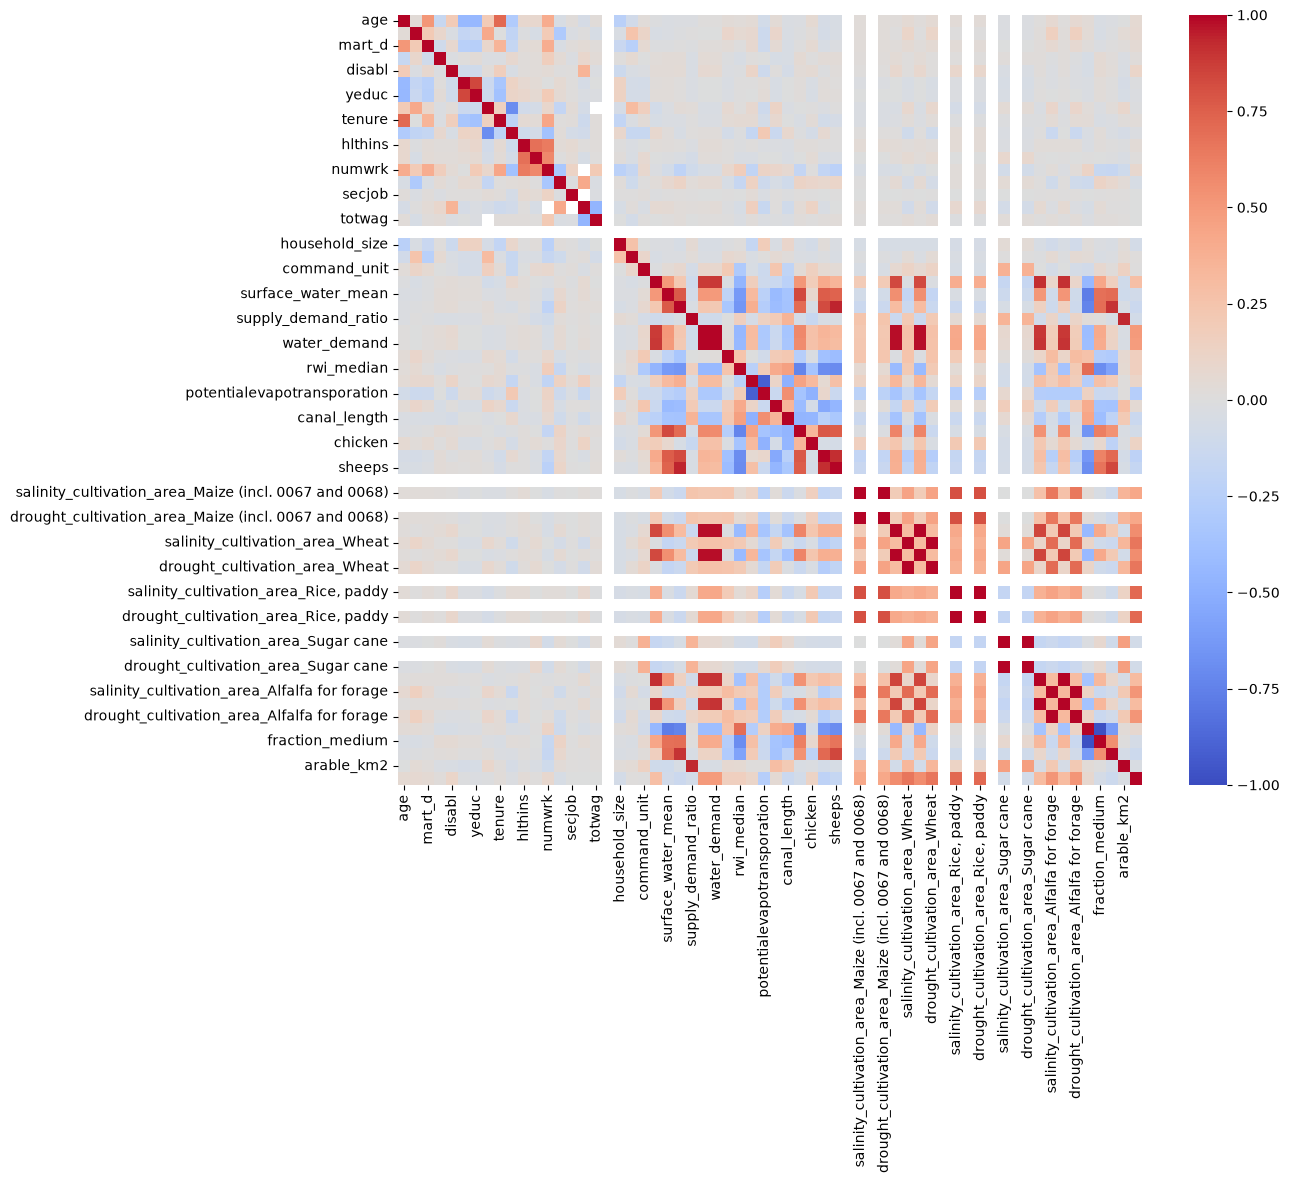

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 10))
sns.heatmap(
    mean_corr_df,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)
plt.show()

In [14]:
corr_long = mean_corr_df.abs().stack().reset_index()

corr_long.columns = ["var1", "var2", "corr"]

corr_long = corr_long[corr_long["var1"] < corr_long["var2"]]

corr_long.sort_values("corr", ascending=False).head(40)

,var1,var2,corr
2770,drought_cultivation_area_Wheat,salinity_cultivation_area_Wheat,0.999999
2518,drought_cultivation_area_Maize (incl. 0067 and...,salinity_cultivation_area_Maize (incl. 0067 an...,0.999999
2707,drought_production_Wheat,salinity_production_Wheat,0.999999
3274,drought_cultivation_area_Sugar cane,salinity_cultivation_area_Sugar cane,0.999999
3526,drought_cultivation_area_Alfalfa for forage,salinity_cultivation_area_Alfalfa for forage,0.999999
3022,"drought_cultivation_area_Rice, paddy","salinity_cultivation_area_Rice, paddy",0.999999
3463,drought_production_Alfalfa for forage,salinity_production_Alfalfa for forage,0.999431
1637,water_demand,water_supply,0.999361
2691,drought_production_Wheat,water_supply,0.982717
2567,salinity_production_Wheat,water_supply,0.982717
